Original Shape: (20000, 24)

Null Values:

accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

Shape After Removing Null Rows: (115, 24)

Duplicate Rows: 0
Shape After Removing Duplicates: (115, 24)

Remaining Columns:

['hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 've

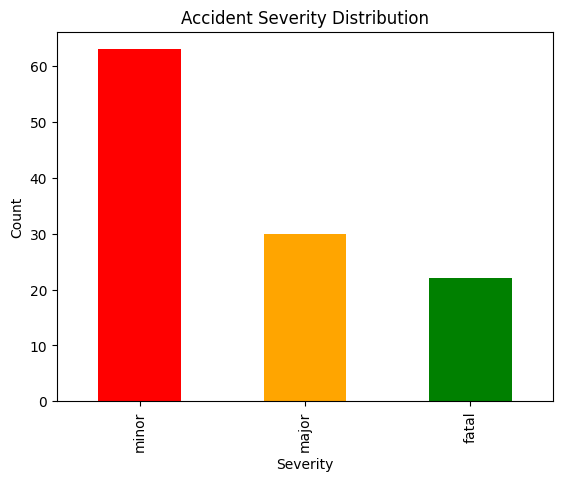

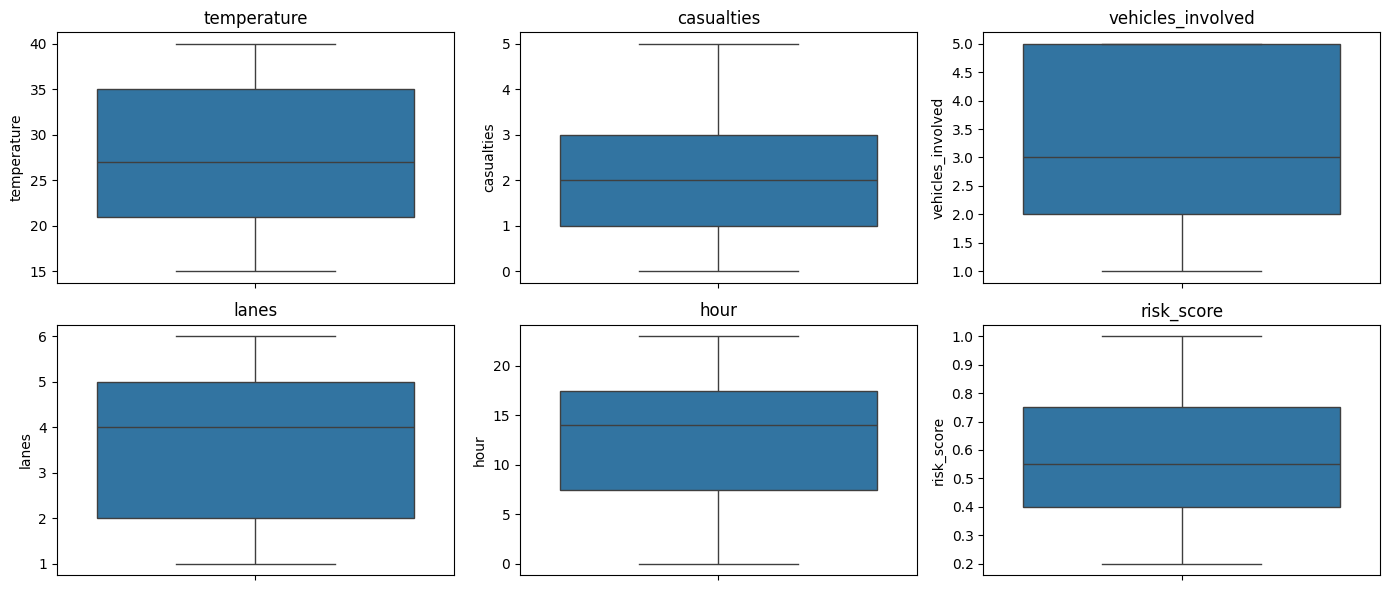


Target Classes:
['fatal' 'major' 'minor']

Feature Shape: (115, 15)

Target Distribution:

accident_severity
2    63
1    30
0    22
Name: count, dtype: int64

Before SMOTE:
{2: 63, 1: 30, 0: 22}

After SMOTE:
{1: 63, 2: 63, 0: 63}

Training Shape: (151, 15)
Testing Shape: (38, 15)

Preprocessing Completed Successfully!


In [6]:

# ==========================================
# COMPLETE PREPROCESSING PIPELINE (UPDATED)
# ==========================================

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# ------------------------------------------
# Load Dataset
# ------------------------------------------
df = pd.read_csv("indian_roads_dataset.csv")

print("Original Shape:", df.shape)

# ------------------------------------------
# Check Null Values
# ------------------------------------------
print("\nNull Values:\n")
print(df.isnull().sum())

# ------------------------------------------
# Remove Rows with Missing Values
# ------------------------------------------
df = df.dropna()

print("\nShape After Removing Null Rows:", df.shape)

# ------------------------------------------
# Remove Duplicate Rows
# ------------------------------------------
print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

# ------------------------------------------
# Drop Unnecessary Columns
# ------------------------------------------
drop_cols = [
    'accident_id',
    'date',
    'time',
    'latitude',
    'longitude',
    'city',
    'state',
    'festival'
]

df = df.drop(columns=drop_cols)

print("\nRemaining Columns:\n")
print(df.columns.tolist())

# ------------------------------------------
# Check Class Distribution
# ------------------------------------------
print("\nClass Distribution:\n")
print(df['accident_severity'].value_counts())

df['accident_severity'].value_counts().plot(
    kind='bar',
    color=['red', 'orange', 'green']
)

plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")

plt.show()

# ------------------------------------------
# Outlier Visualization
# ------------------------------------------
numerical_cols = [
    'temperature',
    'casualties',
    'vehicles_involved',
    'lanes',
    'hour',
    'risk_score'
]

plt.figure(figsize=(14, 6))

for i, col in enumerate(numerical_cols):

    plt.subplot(2, 3, i + 1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

# ------------------------------------------
# Encode Categorical Columns
# ------------------------------------------
categorical_cols = [
    'day_of_week',
    'road_type',
    'weather',
    'visibility',
    'traffic_density',
    'cause'
]

le = LabelEncoder()

for col in categorical_cols:

    df[col] = le.fit_transform(df[col])

# Encode Target Column
le_target = LabelEncoder()

df['accident_severity'] = le_target.fit_transform(
    df['accident_severity']
)

print("\nTarget Classes:")
print(le_target.classes_)

# ------------------------------------------
# Separate Features and Target
# ------------------------------------------
X = df.drop(columns=['accident_severity'])

y = df['accident_severity']

print("\nFeature Shape:", X.shape)

print("\nTarget Distribution:\n")
print(y.value_counts())

# ------------------------------------------
# Handle Class Imbalance using SMOTE
# ------------------------------------------
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nBefore SMOTE:")
print(y.value_counts().to_dict())

print("\nAfter SMOTE:")
print(pd.Series(y_resampled).value_counts().to_dict())

# ------------------------------------------
# Train Test Split
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ------------------------------------------
# Feature Scaling
# ------------------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("\nPreprocessing Completed Successfully!")



First 20 Cluster Predictions:

[0 0 0 1 1 2 2 0 2 2 2 0 2 2 0 0 0 0 0 2]


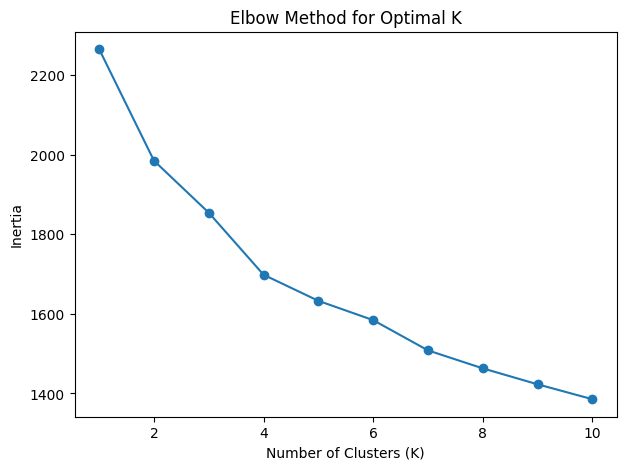

In [7]:
# =========================
# KMEANS CLUSTERING
# =========================

# Imports
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create Model
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

# Train Model
kmeans.fit(X_train)

# Predict Clusters
clusters = kmeans.predict(X_test)

# Display Predictions
print("First 20 Cluster Predictions:\n")
print(clusters[:20])

# -------------------------
# Elbow Method
# -------------------------

inertia_values = []

k_range = range(1, 11)

for k in k_range:

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_train)

    inertia_values.append(model.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(7,5))

plt.plot(
    k_range,
    inertia_values,
    marker='o'
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()